# PA vs. Per-Label Metric Correlation Analysis -- Baseline Models

Same analysis as the HMCN notebook, run across the five fixed-config
baseline models (**KNN, LR, RF, SVM, XGB**) on the 138 fine odor labels.

For each model and each metric (`PR_AUC_mean`, `F1_mean`, `MCC_mean`,
`Sensitivity_mean`) this notebook computes:
1. Spearman rho/p across all labels with defined PA
2. Spearman rho/p restricted to the high-n_PA subset (`n_PA >= median n_PA`)
3. Partial Spearman rho/p between PA and the metric, controlling for n_PA

Labels with `n_molecules == 0` (no GS/LW overlap) have **undefined** PA and
are excluded from all PA-based stats.

Each model's per-label file uses `fine_<label>` naming and a `Bal.Acc_*`
column (period, not underscore) -- both are normalized on load so the merge
lines up with the PA file's `label` column.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr, rankdata
import matplotlib.pyplot as plt

ACCENT = "#1B2A56"      # deep navy
ACCENT_LIGHT = "#7C89B0"
HIGHLIGHT = "#B0552E"   # muted rust
GRID_COLOR = "#DADFE8"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.6,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

MODEL_COLORS = {
    "KNN": "#1B2A56",
    "LR":  "#3E6B8A",
    "RF":  "#2E8B57",
    "SVM": "#B0552E",
    "XGB": "#8A3E6B",
}

In [2]:
# CONFIG
PA_FILE = "/mnt/user-data/uploads/pa_per_label_gs_lw.csv"

MODEL_FILES = {
    "KNN": "/mnt/user-data/uploads/best_config_KNN_fine138.csv",
    "LR":  "/mnt/user-data/uploads/best_config_LR_fine138.csv",
    "RF":  "/mnt/user-data/uploads/best_config_RF_fine138.csv",
    "SVM": "/mnt/user-data/uploads/best_config_SVM_fine138.csv",
    "XGB": "/mnt/user-data/uploads/best_config_XGB_fine138.csv",
}

OUTPUT_SUMMARY_CSV = "/mnt/user-data/outputs/pa_metric_correlation_summary_baselines.csv"

METRICS_TO_TEST = ["PR_AUC_mean", "F1_mean", "MCC_mean", "Sensitivity_mean"]
REFERENCE_METRIC = "PR_AUC_mean"
DIVERGENCE_THRESHOLD = 0.15

## 1. Load PA file and each model's per-label results

In [3]:
def load_model_file(path: str) -> pd.DataFrame:
    m = pd.read_csv(path)
    m = m.rename(columns={"Label": "label", "Bal.Acc_mean": "Bal_Acc_mean",
                           "Bal.Acc_std": "Bal_Acc_std", "Bal.Acc_count": "Bal_Acc_count"})
    m["label"] = m["label"].str.replace("^fine_", "", regex=True)
    return m


def load_and_merge(pa_df: pd.DataFrame, model_df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    merged = pa_df.merge(model_df, on="label", how="inner")
    merged["PA_defined"] = merged["n_molecules"] > 0
    defined = merged.loc[merged["PA_defined"]].copy()

    print(f"[{model_name}] PA labels: {len(pa_df)} | model labels: {len(model_df)} | "
          f"merged: {len(merged)} | defined PA: {len(defined)} "
          f"(excluded {len(merged) - len(defined)})")
    return defined


pa_df = pd.read_csv(PA_FILE)

model_dfs_raw = {name: load_model_file(path) for name, path in MODEL_FILES.items()}
merged_by_model = {name: load_and_merge(pa_df, mdf, name) for name, mdf in model_dfs_raw.items()}

[KNN] PA labels: 138 | model labels: 138 | merged: 138 | defined PA: 130 (excluded 8)
[LR] PA labels: 138 | model labels: 138 | merged: 138 | defined PA: 130 (excluded 8)
[RF] PA labels: 138 | model labels: 138 | merged: 138 | defined PA: 130 (excluded 8)
[SVM] PA labels: 138 | model labels: 138 | merged: 138 | defined PA: 130 (excluded 8)
[XGB] PA labels: 138 | model labels: 138 | merged: 138 | defined PA: 130 (excluded 8)


## 2. Correlation functions (same as HMCN notebook)

In [4]:
def spearman_pair(data: pd.DataFrame, metric: str):
    sub = data[["PA", metric]].dropna()
    if len(sub) < 3:
        return np.nan, np.nan, len(sub)
    rho, p = spearmanr(sub["PA"], sub[metric])
    return rho, p, len(sub)


def partial_spearman(data: pd.DataFrame, metric: str, covariate: str = "n_molecules"):
    sub = data[["PA", metric, covariate]].dropna()
    n = len(sub)
    if n < 4:
        return np.nan, np.nan, n

    r_pa = rankdata(sub["PA"])
    r_metric = rankdata(sub[metric])
    r_cov = rankdata(sub[covariate])

    def residualize(y, x):
        x_design = np.column_stack([np.ones_like(x), x])
        beta, *_ = np.linalg.lstsq(x_design, y, rcond=None)
        return y - x_design @ beta

    resid_pa = residualize(r_pa, r_cov)
    resid_metric = residualize(r_metric, r_cov)

    rho, p = pearsonr(resid_pa, resid_metric)
    return rho, p, n

## 3. Compute summary table across all models and metrics

In [5]:
rows = []
median_n_pa_by_model = {}

for model_name, df in merged_by_model.items():
    median_n_pa = df["n_molecules"].median()
    median_n_pa_by_model[model_name] = median_n_pa
    high_n_df = df[df["n_molecules"] >= median_n_pa]

    for metric in METRICS_TO_TEST:
        rho_all, p_all, n_all = spearman_pair(df, metric)
        rho_high, p_high, n_high = spearman_pair(high_n_df, metric)
        rho_partial, p_partial, n_partial = partial_spearman(df, metric)

        rows.append({
            "model": model_name,
            "metric": metric,
            "n_all": n_all,
            "rho_all": rho_all,
            "p_all": p_all,
            "n_highN": n_high,
            "rho_highN": rho_high,
            "p_highN": p_high,
            "n_partial": n_partial,
            "rho_partial": rho_partial,
            "p_partial": p_partial,
        })

summary = pd.DataFrame(rows)
summary.to_csv(OUTPUT_SUMMARY_CSV, index=False)
summary.style.format({
    "rho_all": "{:.3f}", "p_all": "{:.4f}",
    "rho_highN": "{:.3f}", "p_highN": "{:.4f}",
    "rho_partial": "{:.3f}", "p_partial": "{:.4f}",
})

,model,metric,n_all,rho_all,p_all,n_highN,rho_highN,p_highN,n_partial,rho_partial,p_partial
0,KNN,PR_AUC_mean,130,0.425,0.0000,65,0.387,0.0014,130,0.224,0.0103
1,KNN,F1_mean,130,0.381,0.0000,65,0.396,0.0011,130,0.145,0.0999
2,KNN,MCC_mean,130,0.351,0.0000,65,0.352,0.0040,130,0.171,0.0520
3,KNN,Sensitivity_mean,130,0.384,0.0000,65,0.392,0.0012,130,0.142,0.1059
4,LR,PR_AUC_mean,130,0.416,0.0000,65,0.439,0.0003,130,0.244,0.0051
5,LR,F1_mean,130,0.441,0.0000,65,0.424,0.0004,130,0.231,0.0083
6,LR,MCC_mean,130,0.417,0.0000,65,0.412,0.0006,130,0.264,0.0024
7,LR,Sensitivity_mean,130,0.345,0.0001,65,0.407,0.0008,130,0.180,0.0403
8,RF,PR_AUC_mean,130,0.393,0.0000,65,0.417,0.0006,130,0.215,0.0139
9,RF,F1_mean,130,0.414,0.0000,65,0.389,0.0014,130,0.199,0.0235


## 4. Divergence check vs. PR_AUC_mean, per model

In [6]:
print(f"=== Divergence check vs. {REFERENCE_METRIC} (threshold = {DIVERGENCE_THRESHOLD}) ===")

any_flagged_overall = False
for model_name in MODEL_FILES:
    model_summary = summary[summary["model"] == model_name]
    ref_row = model_summary.loc[model_summary["metric"] == REFERENCE_METRIC].iloc[0]

    model_flagged = False
    for _, row in model_summary.iterrows():
        if row["metric"] == REFERENCE_METRIC:
            continue
        for regime, col in [("all-label", "rho_all"), ("high-n_PA", "rho_highN"),
                             ("partial (controlling n_PA)", "rho_partial")]:
            ref_rho, met_rho = ref_row[col], row[col]
            if pd.isna(ref_rho) or pd.isna(met_rho):
                continue
            diff = met_rho - ref_rho
            if abs(diff) >= DIVERGENCE_THRESHOLD:
                any_flagged_overall = True
                model_flagged = True
                direction = "weaker/reversed relative to" if diff < 0 else "stronger than"
                print(f"  [{model_name} | {regime}] {row['metric']} rho={met_rho:.3f} vs "
                      f"{REFERENCE_METRIC} rho={ref_rho:.3f} (diff={diff:+.3f}) "
                      f"-> {direction} PR_AUC's PA relationship.")
    if not model_flagged:
        print(f"  [{model_name}] no metric diverges from {REFERENCE_METRIC} by >= {DIVERGENCE_THRESHOLD}.")

if not any_flagged_overall:
    print(f"\nNo model/metric combination diverges from {REFERENCE_METRIC} by >= "
          f"{DIVERGENCE_THRESHOLD} in any regime.")

=== Divergence check vs. PR_AUC_mean (threshold = 0.15) ===
  [KNN] no metric diverges from PR_AUC_mean by >= 0.15.
  [LR] no metric diverges from PR_AUC_mean by >= 0.15.
  [RF] no metric diverges from PR_AUC_mean by >= 0.15.
  [SVM] no metric diverges from PR_AUC_mean by >= 0.15.
  [XGB] no metric diverges from PR_AUC_mean by >= 0.15.

No model/metric combination diverges from PR_AUC_mean by >= 0.15 in any regime.


## 5. Plots

### 5.1 rho_partial (PA vs. PR_AUC, controlling n_PA) across models
This is the cleanest single number for "does PA predict ranking quality once sample-size confound is removed", compared across the five baselines.

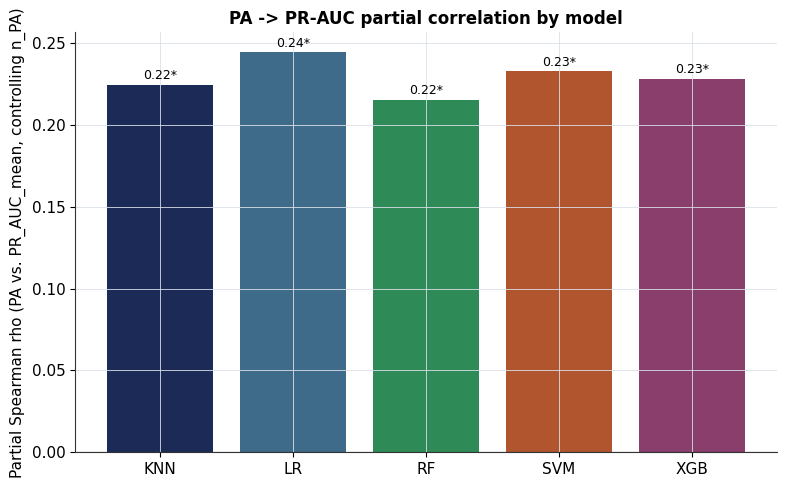

In [7]:
pr_auc_summary = summary[summary["metric"] == "PR_AUC_mean"].set_index("model")
models_order = list(MODEL_FILES.keys())

fig, ax = plt.subplots(figsize=(8, 5))
colors = [MODEL_COLORS[m] for m in models_order]
bars = ax.bar(models_order, pr_auc_summary.loc[models_order, "rho_partial"], color=colors)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_ylabel("Partial Spearman rho (PA vs. PR_AUC_mean, controlling n_PA)")
ax.set_title("PA -> PR-AUC partial correlation by model")

for bar, (_, row) in zip(bars, pr_auc_summary.loc[models_order].iterrows()):
    sig = "*" if row["p_partial"] < 0.05 else ""
    ax.annotate(f"{row['rho_partial']:.2f}{sig}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                textcoords="offset points", xytext=(0, 4 if bar.get_height() >= 0 else -14),
                ha="center", fontsize=9)

fig.tight_layout()
plt.show()

### 5.2 rho comparison across all metrics and regimes, per model

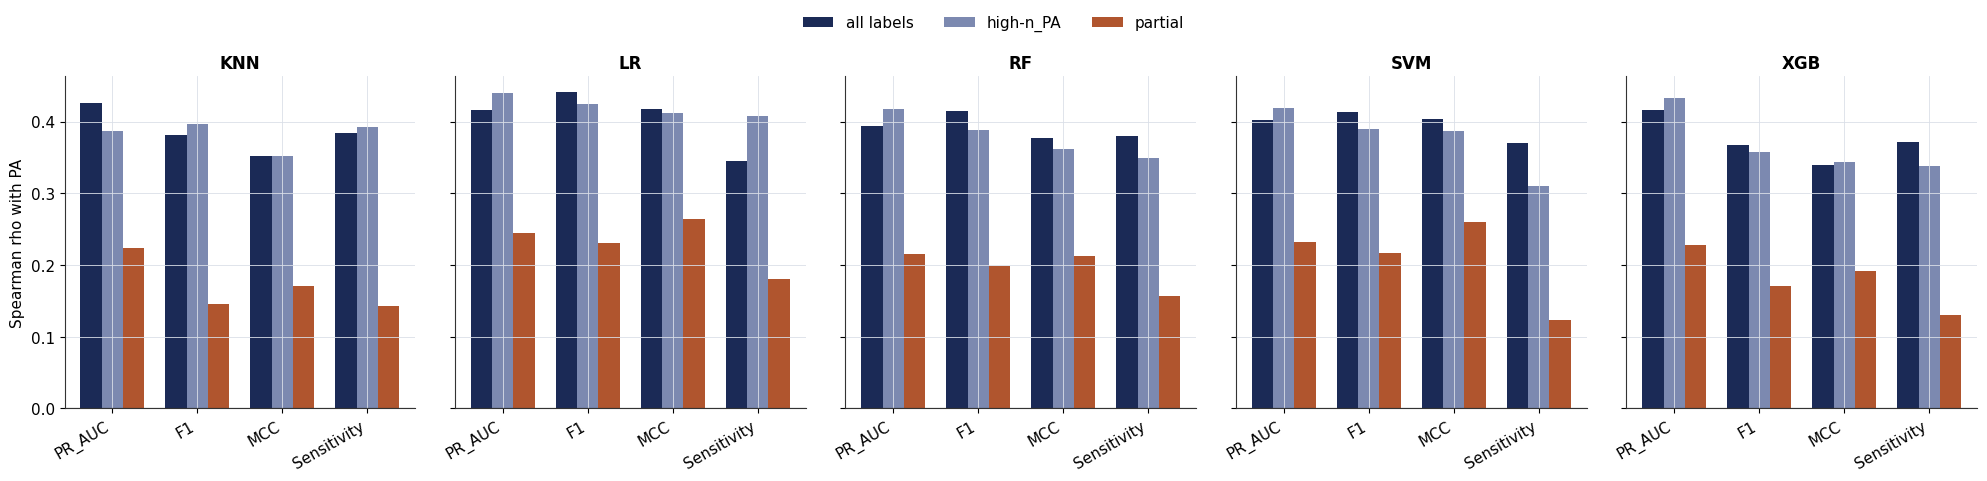

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5), sharey=True)

x = np.arange(len(METRICS_TO_TEST))
width = 0.25

for ax, model_name in zip(axes, models_order):
    model_summary = summary[summary["model"] == model_name].set_index("metric").loc[METRICS_TO_TEST]
    ax.bar(x - width, model_summary["rho_all"], width, label="all labels", color=ACCENT)
    ax.bar(x, model_summary["rho_highN"], width, label="high-n_PA", color=ACCENT_LIGHT)
    ax.bar(x + width, model_summary["rho_partial"], width, label="partial", color=HIGHLIGHT)
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("_mean", "") for m in METRICS_TO_TEST], rotation=30, ha="right")
    ax.set_title(model_name)

axes[0].set_ylabel("Spearman rho with PA")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()
plt.show()

### 5.3 PA vs. PR_AUC scatter, one panel per model (color = n_PA)

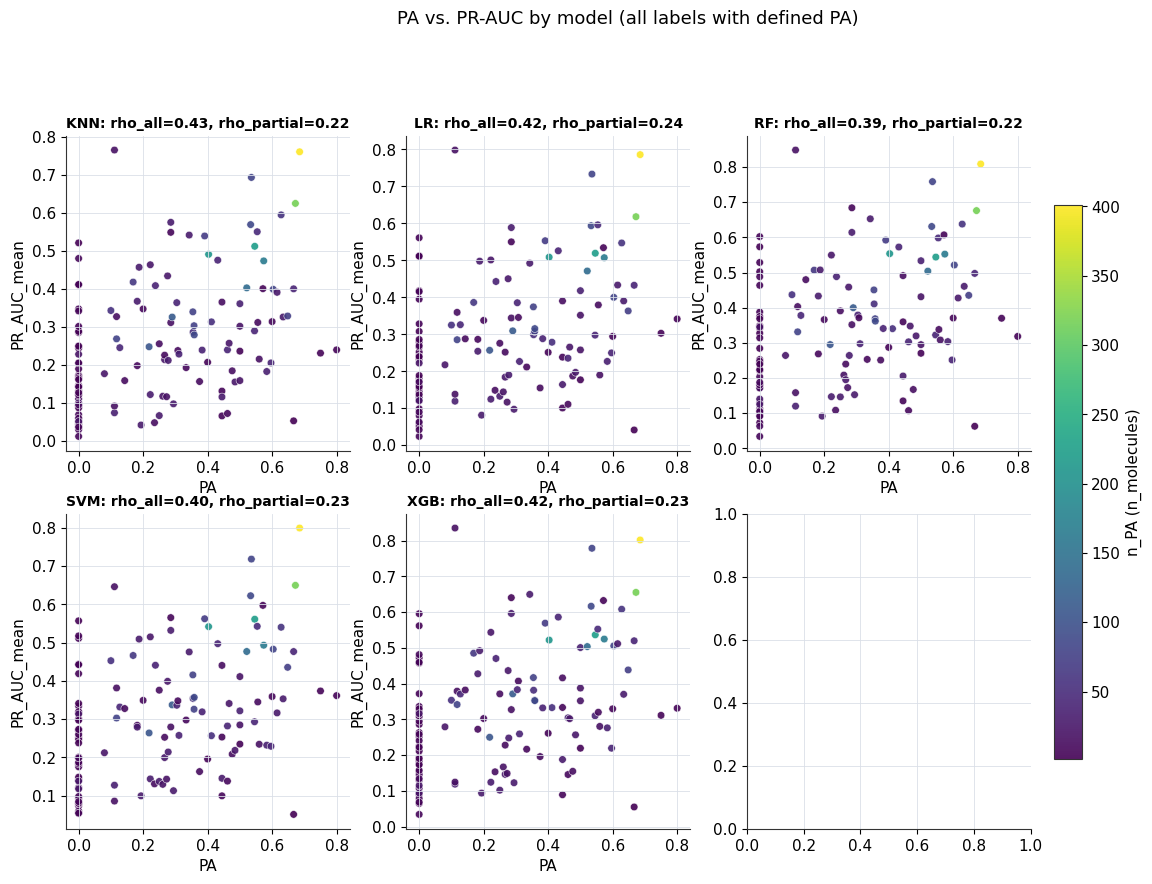

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flat

for ax, model_name in zip(axes_flat, models_order):
    df = merged_by_model[model_name]
    sub = df[["PA", "PR_AUC_mean", "n_molecules"]].dropna()
    sc = ax.scatter(sub["PA"], sub["PR_AUC_mean"], c=sub["n_molecules"], cmap="viridis",
                     s=30, edgecolor="white", linewidth=0.4, alpha=0.9)
    row = summary[(summary["model"] == model_name) & (summary["metric"] == "PR_AUC_mean")].iloc[0]
    ax.set_title(f"{model_name}: rho_all={row['rho_all']:.2f}, rho_partial={row['rho_partial']:.2f}",
                 fontsize=10)
    ax.set_xlabel("PA")
    ax.set_ylabel("PR_AUC_mean")

# hide the unused 6th panel
for ax in axes_flat:
    if not ax.has_data():
        ax.axis("off")

cbar = fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label("n_PA (n_molecules)")
fig.suptitle("PA vs. PR-AUC by model (all labels with defined PA)", y=1.02, fontsize=13)
plt.show()

### 5.4 Cross-model comparison: rho_all vs. rho_partial for PR_AUC
How much each model's raw PA-PR_AUC correlation shrinks once n_PA is controlled for -- a big drop means the raw correlation was mostly a sample-size artifact for that model.

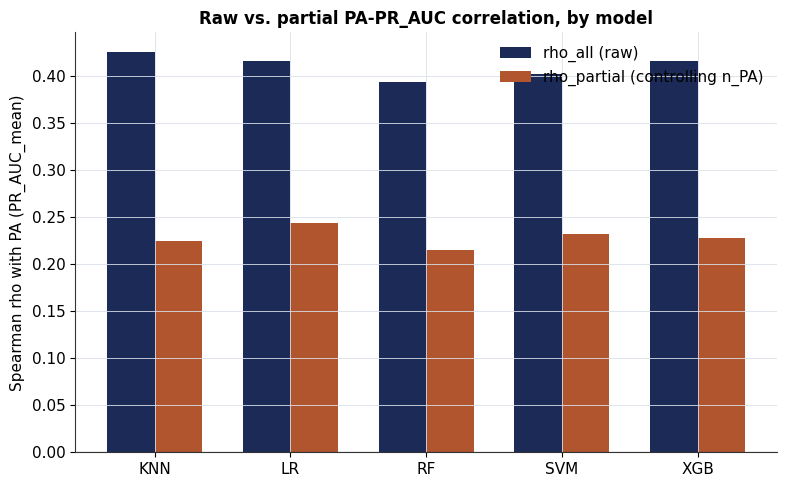

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(models_order))
width = 0.35

ax.bar(x - width / 2, pr_auc_summary.loc[models_order, "rho_all"], width,
       label="rho_all (raw)", color=ACCENT)
ax.bar(x + width / 2, pr_auc_summary.loc[models_order, "rho_partial"], width,
       label="rho_partial (controlling n_PA)", color=HIGHLIGHT)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models_order)
ax.set_ylabel("Spearman rho with PA (PR_AUC_mean)")
ax.set_title("Raw vs. partial PA-PR_AUC correlation, by model")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Notes

- All five baselines are merged against the **same PA file**
  (`pa_per_label_gs_lw.csv`), so any cross-model differences reflect the
  models' own per-label metric profiles, not a different PA source.
- As with HMCN, expect the **raw** PA-PR_AUC correlation (`rho_all`) to be
  driven substantially by `n_PA`: the **partial** correlation
  (`rho_partial`, controlling for `n_PA`) is the more trustworthy number for
  claims like "PA predicts PR-AUC independent of sample size."
- If a specific model's `rho_partial` stays meaningfully positive while
  others collapse toward zero, that's worth a closer look -- it would mean
  PA carries independent signal for that model's predictions specifically,
  not just as a proxy for how much training/eval data a label had.